#  K-Means Clustering

## The Idea
Group similar data points together WITHOUT labels.

## How It Works
1. Choose K (number of clusters)
2. Randomly place K centroids
3. Assign each point to nearest centroid
4. Move centroids to center of their points
5. Repeat 3-4 until centroids stop moving

## Key Question
How to choose K? → **Elbow Method**

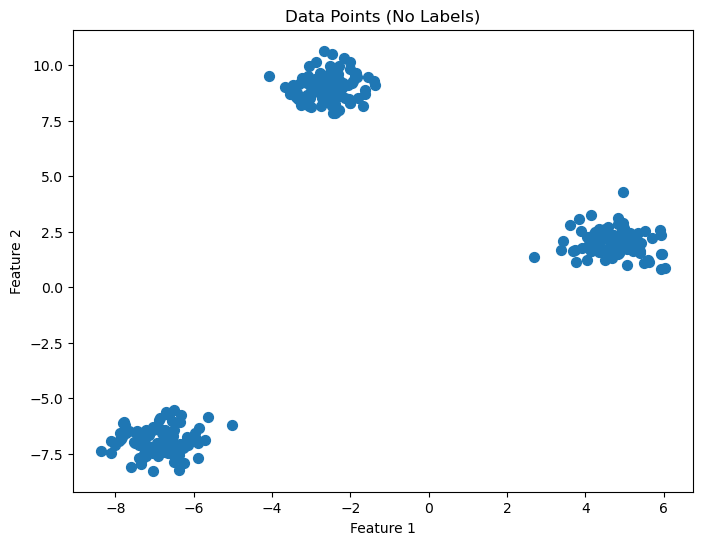

In [1]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

# Create sample data with 3 clusters
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=42)

# Visualize
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Data Points (No Labels)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Cluster Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]

Cluster Centers:
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


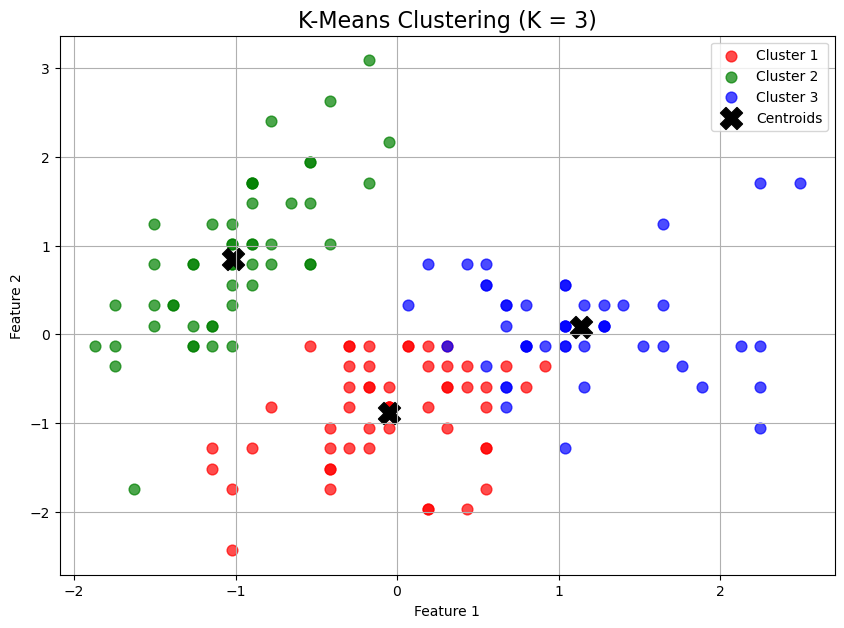

Cluster 1: 53 samples
Cluster 2: 50 samples
Cluster 3: 47 samples


In [5]:

# K-Means Clustering (K = 3)
# Fix Windows MKL warning (must be before sklearn import)
import os
os.environ["OMP_NUM_THREADS"] = "2"
# Ignore warnings (optional)
import warnings
warnings.filterwarnings("ignore")

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load Dataset

iris = load_iris()
X = iris.data

# Scale the data (recommended for K-Means)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train K-Means Model

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

# Cluster labels
labels = kmeans.labels_

# Cluster centroids
centroids = kmeans.cluster_centers_

# Print Results

print("Cluster Labels:")
print(labels)

print("\nCluster Centers:")
print(centroids)

# Visualize Clusters
# (Using first two features)

plt.figure(figsize=(10, 7))

colors = ["red", "green", "blue"]

for i in range(3):
    plt.scatter(
        X[labels == i, 0],
        X[labels == i, 1],
        color=colors[i],
        s=60,
        alpha=0.7,
        label=f"Cluster {i+1}"
    )

# Plot Centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    color="black",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("K-Means Clustering (K = 3)", fontsize=16)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

# Number of Samples in Each Cluster

for i in range(3):
    print(f"Cluster {i+1}: {(labels == i).sum()} samples")

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Shape of Dataset:
(150, 4)


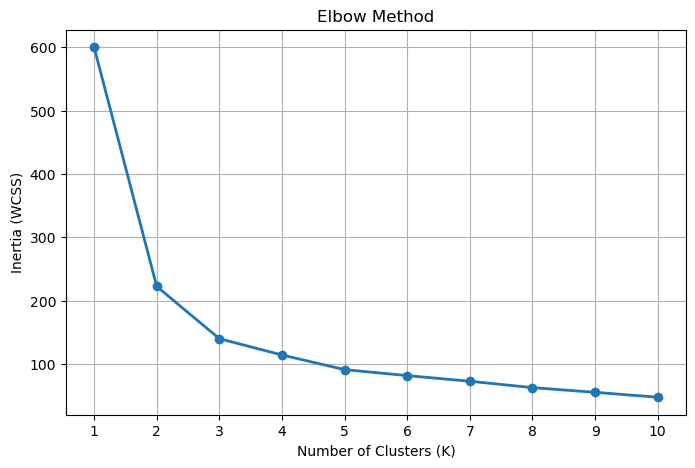

Choose the K where the curve bends (Elbow Point).

First 10 Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   Cluster  
0        1  
1        1  
2        1  
3        1  

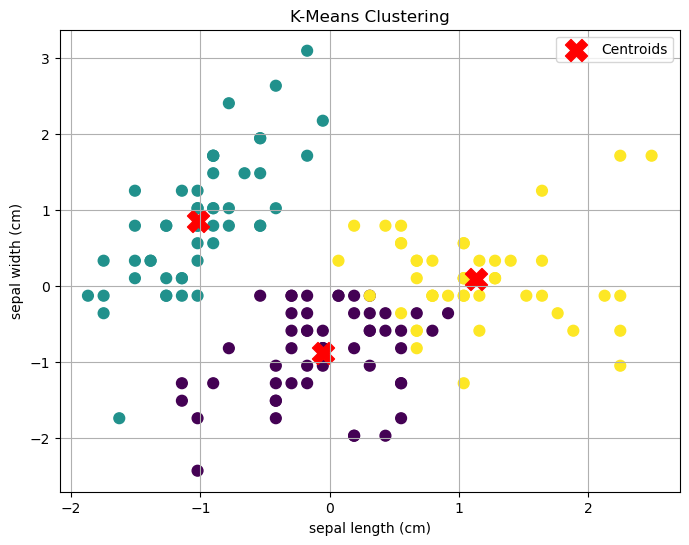


Cluster Counts:
Cluster
0    53
1    50
2    47
Name: count, dtype: int64


In [4]:

# K-Means Clustering - Elbow Method

# Fix Windows MKL warning
import os
os.environ["OMP_NUM_THREADS"] = "2"

# Import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load Dataset

iris = load_iris()

# Features only
X = iris.data

# Feature names (optional)
print("Feature Names:")
print(iris.feature_names)

print("\nShape of Dataset:")
print(X.shape)

# Scale the Data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot Elbow Curve

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o', linewidth=2)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.xticks(K_range)
plt.grid(True)
plt.show()

print("Choose the K where the curve bends (Elbow Point).")

# Train Final Model

optimal_k = 3   # Change if your elbow suggests another value

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Add Cluster Labels

df = pd.DataFrame(X, columns=iris.feature_names)
df["Cluster"] = clusters

print("\nFirst 10 Rows:")
print(df.head(10))

# Cluster Centers

print("\nCluster Centers (Scaled Data):")
print(kmeans.cluster_centers_)

# Visualize Clusters
# (Using first two features)

plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap='viridis',
    s=60
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color='red',
    marker='X',
    s=250,
    label='Centroids'
)

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("K-Means Clustering")
plt.legend()
plt.grid(True)
plt.show()

# Number of Samples in Each Cluster

print("\nCluster Counts:")
print(df["Cluster"].value_counts().sort_index())